# A2.1 Regresión logística y validación cruzada 

En esta actividad trabajarás con la misma base de datos que trabajaste en el proyecto del primer 
parcial.  Desarrolla  los  siguientes  puntos  en  una Jupyter  Notebook,  tratando,  dentro  de  lo  posible,  que  cada  punto  se  trabaje  en  una  celda  distinta.  Los  comentarios  en  el  código  siempre  son  bienvenidos, de preferencia, aprovecha el markdown para generar cuadros de descripción que ayuden al lector a comprender el trabajo realizado. 


1. Importa  los  datos  a  tu  ambiente  de  trabajo.  Especifica  qué  variable  utilizarás  como  variable  de  salida,  debe  tratarse  de  una  variable  binaria.  Si  no  hay  ninguna  variable binaria de interés, binariza la variable de salida que utilizaste en el proyecto (si trataste de predecir el precio de las casas, genera una variable que indique si una casa cuesta 
más que cierto monto, o menos). 

In [5]:
import pandas as pd

df = pd.read_csv("possum.csv")

print("La variable de interés en este caso será el sexo del tlacuache")

# Eliminamos las columnas que no son necesarias como case, site, y Pop
df = df.drop(columns=["case", "site", "Pop"])

# Convertimos la columna sex de m y f a una de Male con 1 y 0
df["sex"] = df["sex"].replace({"m": 1, "f": 0})

# Checamos huecos en los datos
df.isnull().sum()
# Eliminamos las filas con datos faltantes ya que son pocos
df = df.dropna()

df.head()

La variable de interés en este caso será el sexo del tlacuache


C:\Users\diego\AppData\Local\Temp\ipykernel_27304\781057598.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sex"] = df["sex"].replace({"m": 1, "f": 0})


,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,0,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,0,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,0,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,0,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


2. Separa los datos en entrenamiento y prueba, con una relación de 80/20. Asegúrate de mantener  un  balance  de  clases  (es  decir,  si  en  la  base  de  datos  hay  70%  de  observaciones de clase 0 y 30% de observaciones de clase 1, deberá mantenerse una proporción muy similar  tanto en los datos de entrenamiento como en los de prueba), e imprime  en  consola  las  proporciones  para  los  3  grupos  (datos  originales,  datos  de  entrenamiento, datos de prueba). 

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["sex"])
y = df["sex"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,          # 20%
    stratify=y              # mantiene la proporción
)

# Imprimimos las proporciones de los tres grupos de datos
print("Proporción de clases en los datos originales:")
print(y.value_counts(normalize=True))
print("\nProporción de clases en los datos de entrenamiento:")
print(y_train.value_counts(normalize=True))
print("\nProporción de clases en los datos de prueba:")
print(y_test.value_counts(normalize=True))

Proporción de clases en los datos originales:
sex
1    0.584158
0    0.415842
Name: proportion, dtype: float64

Proporción de clases en los datos de entrenamiento:
sex
1    0.5875
0    0.4125
Name: proportion, dtype: float64

Proporción de clases en los datos de prueba:
sex
1    0.571429
0    0.428571
Name: proportion, dtype: float64


3. Usando los datos de entrenamiento, mide la exactitud de un modelo de regresión logística 
usando  alguna  técnica  de  validación  cruzada.  Si  tu  base  de  datos  era  particularmente  
compleja, puedes trabajar con 5 características de interés, en vez de con toda la base de 
datos, o de tener que realizar un proceso de selección de características.

In [7]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)

cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring="accuracy")

print("Exactitud en cada fold:", cv_scores)
print("Exactitud promedio (5-fold CV):", cv_scores.mean())

Exactitud en cada fold: [0.5    0.375  0.625  0.8125 0.625 ]
Exactitud promedio (5-fold CV): 0.5875


4. Entrena  un  modelo  de  regresión  logística,  similar  al  del  punto  anterior,  pero  utilizando todo el subconjunto de datos de entrenamiento. Usando dicho modelo, genera un vector de probabilidades para los datos de prueba. Genera una matriz de confusión y reporta la exactitud, sensibilidad y especificidad del modelo antes 3 diferentes umbrales (0.5, uno mayor, y uno menor).

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_prob = log_reg.predict_proba(X_test)[:, 1]

def evaluar_umbral(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)  # TPR
    spec = recall_score(y_true, y_pred, pos_label=0)  # TNR
    return cm, acc, sens, spec

for thr in [0.3, 0.5, 0.7]:
    cm, acc, sens, spec = evaluar_umbral(y_test, y_prob, thr)
    print(f"\nUmbral = {thr}")
    print("Matriz de confusión:\n", cm)
    print(f"Exactitud: {acc:.3f}")
    print(f"Sensibilidad (TPR): {sens:.3f}")
    print(f"Especificidad (TNR): {spec:.3f}")


Umbral = 0.3
Matriz de confusión:
 [[ 0  9]
 [ 1 11]]
Exactitud: 0.524
Sensibilidad (TPR): 0.917
Especificidad (TNR): 0.000

Umbral = 0.5
Matriz de confusión:
 [[4 5]
 [5 7]]
Exactitud: 0.524
Sensibilidad (TPR): 0.583
Especificidad (TNR): 0.444

Umbral = 0.7
Matriz de confusión:
 [[6 3]
 [8 4]]
Exactitud: 0.476
Sensibilidad (TPR): 0.333
Especificidad (TNR): 0.667


5. Grafica la curva ROC para las probabilidades calculadas en el punto previo y reporta el 
valor de la AUC.

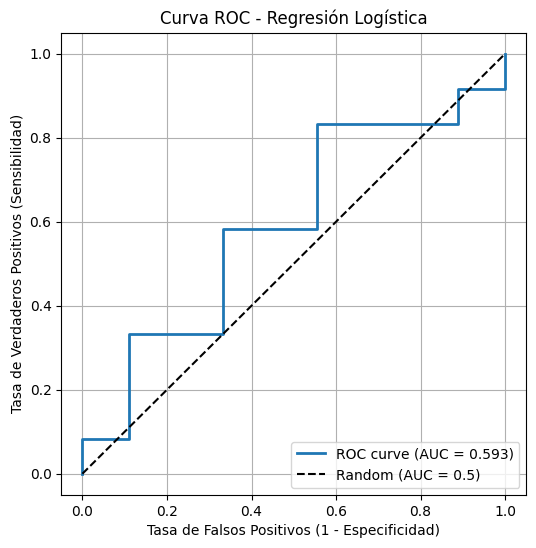

Valor del AUC: 0.593


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})", linewidth=2)
plt.plot([0,1], [0,1], "k--", label="Random (AUC = 0.5)")  # línea aleatoria
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Valor del AUC: {auc:.3f}")

6. Interpreta los resultados del modelo, describiendo cómo es que cada variable afecta a la 
salida, en términos de los coeficientes generados. 

In [15]:
import numpy as np

# Obtener coeficientes del modelo
coef = log_reg.coef_[0]
intercept = log_reg.intercept_[0]

# Asociar coeficientes con los nombres de las variables
for feature, c in zip(X.columns, coef):
    print(f"{feature}: {c:.4f} (exp={np.exp(c):.3f})")

print(f"\nIntercepto: {intercept:.4f}")


age: 0.0138 (exp=1.014)
hdlngth: 0.3613 (exp=1.435)
skullw: 0.0929 (exp=1.097)
totlngth: -0.3242 (exp=0.723)
taill: 0.1366 (exp=1.146)
footlgth: -0.0306 (exp=0.970)
earconch: 0.0080 (exp=1.008)
eye: 0.4156 (exp=1.515)
chest: -0.2227 (exp=0.800)
belly: -0.1198 (exp=0.887)

Intercepto: -9.7175


age: 0.0138 (exp=1.014)
Cada año extra de edad aumenta los odds de ser macho en 1.4%. El efecto es muy pequeño.

hdlngth: 0.3613 (exp=1.435)
Por cada unidad adicional en la longitud de la cabeza, los odds de ser macho aumentan 43.5%. Es un predictor relevante y positivo.

totlngth: -0.3242 (exp=0.723)
A mayor longitud total del cuerpo, disminuyen los odds de ser macho en 27.7%. Es decir, los animales más largos tienden a ser hembras.

eye: 0.4156 (exp=1.515)
Cada unidad más en el tamaño del ojo incrementa los odds de ser macho en 51.5%. Es uno de los predictores más fuertes.

chest: -0.2227 (exp=0.800)
A mayor ancho de pecho, los odds de ser macho bajan en 20%. Tiende a asociarse más con hembras.

Intercepto: -9.7175
Representa la probabilidad base de ser macho cuando todas las variables son cero (no tiene interpretación biológica directa, pero ayuda a ajustar la escala del modelo).